# Линейная регрессия и градиентные методы с нуля

В этом ноутбуке я разбираю линейную регрессию не как `sklearn.fit`, а как набор реализованных компонентов: loss functions, optimizers, learning rate schedules, регуляризация и сравнение методов на реальном табличном датасете автомобилей.


## 1. Closed-form solution и проверка собственной Linear Regression

Сначала проверяю аналитическое решение MSE и сравниваю собственную реализацию с `sklearn.linear_model.LinearRegression`. Отдельно рассматриваю случай мультиколлинеарности и SVD-решение.


In [1]:
import numpy as np
import sys
from pathlib import Path
sys.path.extend([str(Path.cwd() / "src"), str(Path.cwd().parent / "src")])
from linear_models_gd import MSELoss, CustomLinearRegression, AnalyticSolutionOptimizer
num_objects = 100
dimension = 5

x = np.random.rand(num_objects, dimension)
y = np.random.rand(num_objects)


In [2]:
from sklearn.metrics import mean_squared_error as mse
import sklearn

sklearn_linreg = sklearn.linear_model.LinearRegression(fit_intercept=False)
sklearn_linreg.fit(x, y)
print("Sklearn MSE\t", mse(sklearn_linreg.predict(x), y))

your_linreg = CustomLinearRegression(AnalyticSolutionOptimizer(), loss_function=MSELoss())
your_linreg.fit(x, y)
print("Your MSE\t", mse(your_linreg.predict(x), y))

assert abs(mse(your_linreg.predict(x), y) - mse(sklearn_linreg.predict(x), y)) < 1e-12, "Не повезло, попробуйте еще раз"


Sklearn MSE	 0.1064156391944692
Your MSE	 0.1064156391944692


In [3]:
x[:, 3] = x[:, 2] + x[:, 4]


In [4]:
sklearn_linreg = sklearn.linear_model.LinearRegression(fit_intercept=False)
sklearn_linreg.fit(x, y)
print("Sklearn MSE\t", mse(sklearn_linreg.predict(x), y))

your_linreg = CustomLinearRegression(AnalyticSolutionOptimizer(), loss_function=MSELoss())
your_linreg.fit(x, y)
print("Your MSE\t", mse(your_linreg.predict(x), y))


Sklearn MSE	 0.10946134098777799
Your MSE	 0.11868845320861356


In [5]:
sklearn_linreg = sklearn.linear_model.LinearRegression(fit_intercept=False)
sklearn_linreg.fit(x, y)
print("Sklearn MSE", mse(sklearn_linreg.predict(x), y))


your_linreg =  CustomLinearRegression(AnalyticSolutionOptimizer(),
                                      loss_function=MSELoss(analytic_solution_func=MSELoss._svd_analytic_solution))
your_linreg.fit(x, y)

print("Your MSE", mse(your_linreg.predict(x), y))

assert abs(mse(your_linreg.predict(x), y) - mse(sklearn_linreg.predict(x), y)) < 1e-12, "Не повезло, попробуйте еще раз"


Sklearn MSE 0.10946134098777799
Your MSE 0.10946134098777799


### Результаты блока

| Проверка | MSE sklearn | MSE custom |
|---|---:|---:|
| Обычная матрица признаков | 0.1064 | 0.1064 |
| Мультиколлинеарность, naive inverse | 0.1095 | 0.1187 |
| Мультиколлинеарность, SVD solution | 0.1095 | 0.1095 |

Вывод: классическая формула через обратную матрицу нестабильна при вырожденности `X.T @ X`, а SVD-решение восстанавливает качество `sklearn`.


## 2. Реализация оптимизаторов

В модуль `src/linear_models_gd` вынесены реализации Vanilla GD, SGD, SAG, Momentum и Adam. Все оптимизаторы работают через общий интерфейс модели и не знают конкретную функцию потерь.


In [6]:
%load_ext autoreload


In [7]:
#%autoreload 2

from linear_models_gd import (
   VanillaGradientDescent,
   StochasticGradientDescent,
   SAGDescent,
   MomentumDescent,
   Adam
)

from linear_models_gd import CustomLinearRegression


In [8]:
num_objects = 100
dimension = 5

x = np.random.rand(num_objects, dimension)
y = np.random.rand(num_objects)


In [9]:
descent_models = [
   VanillaGradientDescent,
   StochasticGradientDescent,
   SAGDescent,
   MomentumDescent,
   Adam
]

max_iter = 10
tolerance = 0
num_objects = 100
dimension = 5

for descent_model in descent_models:
   optimizer = descent_model(tolerance=tolerance, max_iter=max_iter)
   model = CustomLinearRegression(optimizer=optimizer)
   model.fit(x, y)
   assert len(model.loss_history) == max_iter + 1, "Loss history failed"
   y_pred = model.predict(x)
   assert y_pred.shape == y.shape, "Prediction shape does not match target variable"


### Результаты блока

Локальный smoke-test проверяет, что все оптимизаторы запускаются на синтетических данных и корректно обновляют веса модели. Это базовая проверка архитектуры перед экспериментами на реальных данных.


## 3. Данные автомобилей и preprocessing

Далее использую датасет объявлений о продаже автомобилей. Цель — предсказать `log_price`. Перед обучением очищаю выбросы, анализирую числовые и категориальные признаки, добавляю bias и собираю preprocessing через `ColumnTransformer`.


In [10]:
import numpy as np
import pandas as pd  # при желании, можете заменить на polars/pyspark или что угодно, что вам нравится

import matplotlib.pyplot as plt
import seaborn as sns

from linear_models_gd import (
    ConstantLR, TimeDecayLR,
    VanillaGradientDescent, StochasticGradientDescent,
    MomentumDescent, Adam, SAGDescent
)
from linear_models_gd import CustomLinearRegression

sns.set(style='darkgrid')


In [11]:
data = pd.read_csv('../data/raw/autos.csv')


In [12]:
data.head()


,brand,model,vehicleType,gearbox,fuelType,notRepairedDamage,powerPS,kilometer,autoAgeMonths,price
0,volkswagen,golf,kleinwagen,manuell,benzin,nein,75,150000,177,1500
1,skoda,fabia,kleinwagen,manuell,diesel,nein,69,90000,93,3600
2,bmw,3er,limousine,manuell,benzin,ja,102,150000,246,650
3,peugeot,2_reihe,cabrio,manuell,benzin,nein,109,150000,140,2200
4,mazda,3_reihe,limousine,manuell,benzin,nein,105,150000,136,2000


In [13]:
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 241190 entries, 0 to 241189
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   brand              241190 non-null  str  
 1   model              241190 non-null  str  
 2   vehicleType        241190 non-null  str  
 3   gearbox            241190 non-null  str  
 4   fuelType           241190 non-null  str  
 5   notRepairedDamage  241190 non-null  str  
 6   powerPS            241190 non-null  int64
 7   kilometer          241190 non-null  int64
 8   autoAgeMonths      241190 non-null  int64
 9   price              241190 non-null  int64
dtypes: int64(4), str(6)
memory usage: 18.4 MB


<Axes: xlabel='price', ylabel='Count'>

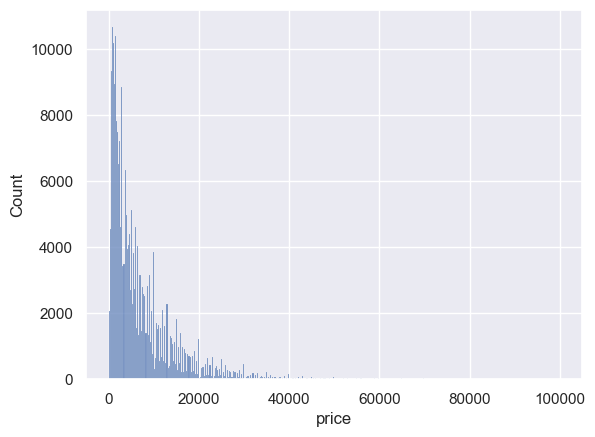

In [14]:
sns.histplot(data=data, x='price')


In [15]:
data['price'].describe() #проверил, что нет нулевой цены


count    241190.000000
mean       6887.741892
std        8024.451993
min           1.000000
25%        1750.000000
50%        4100.000000
75%        8999.000000
max       99999.000000
Name: price, dtype: float64

<Axes: xlabel='log_price'>

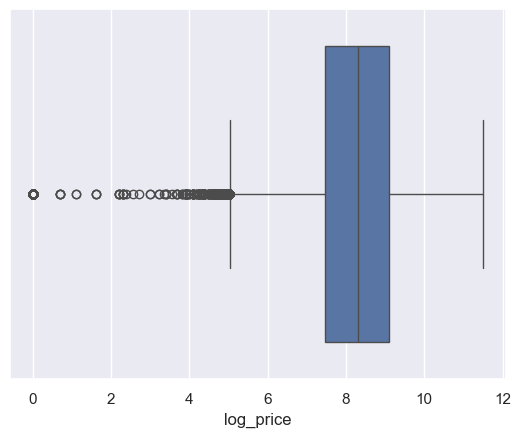

In [16]:
data['log_price'] = np.log(data['price'])
data.drop('price', axis=1, inplace=True)
sns.boxplot(x=data['log_price'])


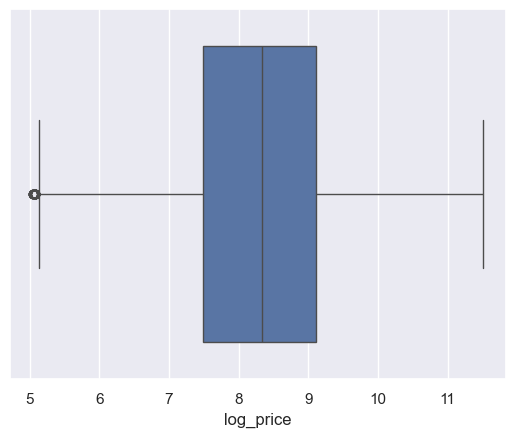

In [17]:
q1 = data['log_price'].quantile(0.25)
q3 = data['log_price'].quantile(0.75)
iqr = q3 - q1
low = q1 - 1.5 * iqr
high = q3 + 1.5 * iqr

data = data[data['log_price'].between(low, high)].copy()

sns.boxplot(x=data['log_price'])
plt.show()


<Axes: xlabel='log_price', ylabel='Count'>

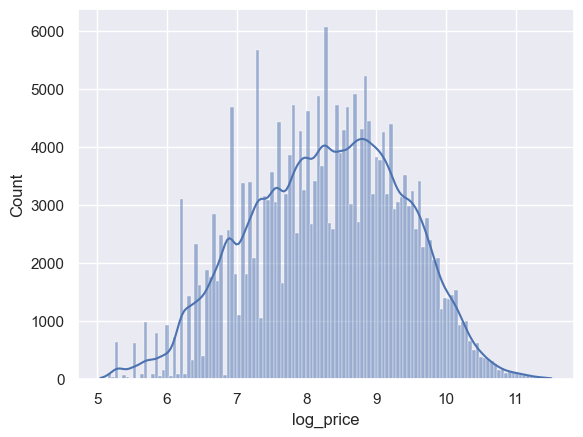

In [18]:
sns.histplot(data=data, x='log_price', kde=True)


In [19]:
data.info()


<class 'pandas.DataFrame'>
Index: 240034 entries, 0 to 241189
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   brand              240034 non-null  str    
 1   model              240034 non-null  str    
 2   vehicleType        240034 non-null  str    
 3   gearbox            240034 non-null  str    
 4   fuelType           240034 non-null  str    
 5   notRepairedDamage  240034 non-null  str    
 6   powerPS            240034 non-null  int64  
 7   kilometer          240034 non-null  int64  
 8   autoAgeMonths      240034 non-null  int64  
 9   log_price          240034 non-null  float64
dtypes: float64(1), int64(3), str(6)
memory usage: 20.1 MB


In [20]:
categorical = []
numeric = []
other = []

for col in data.columns:
    if data[col].dtype == 'str':
        categorical.append(col)
    elif data[col].dtype == 'int64' or data[col].dtype == 'float64':
        numeric.append(col)
    else:
        other.append(col)
numeric.pop(numeric.index('log_price'))


'log_price'

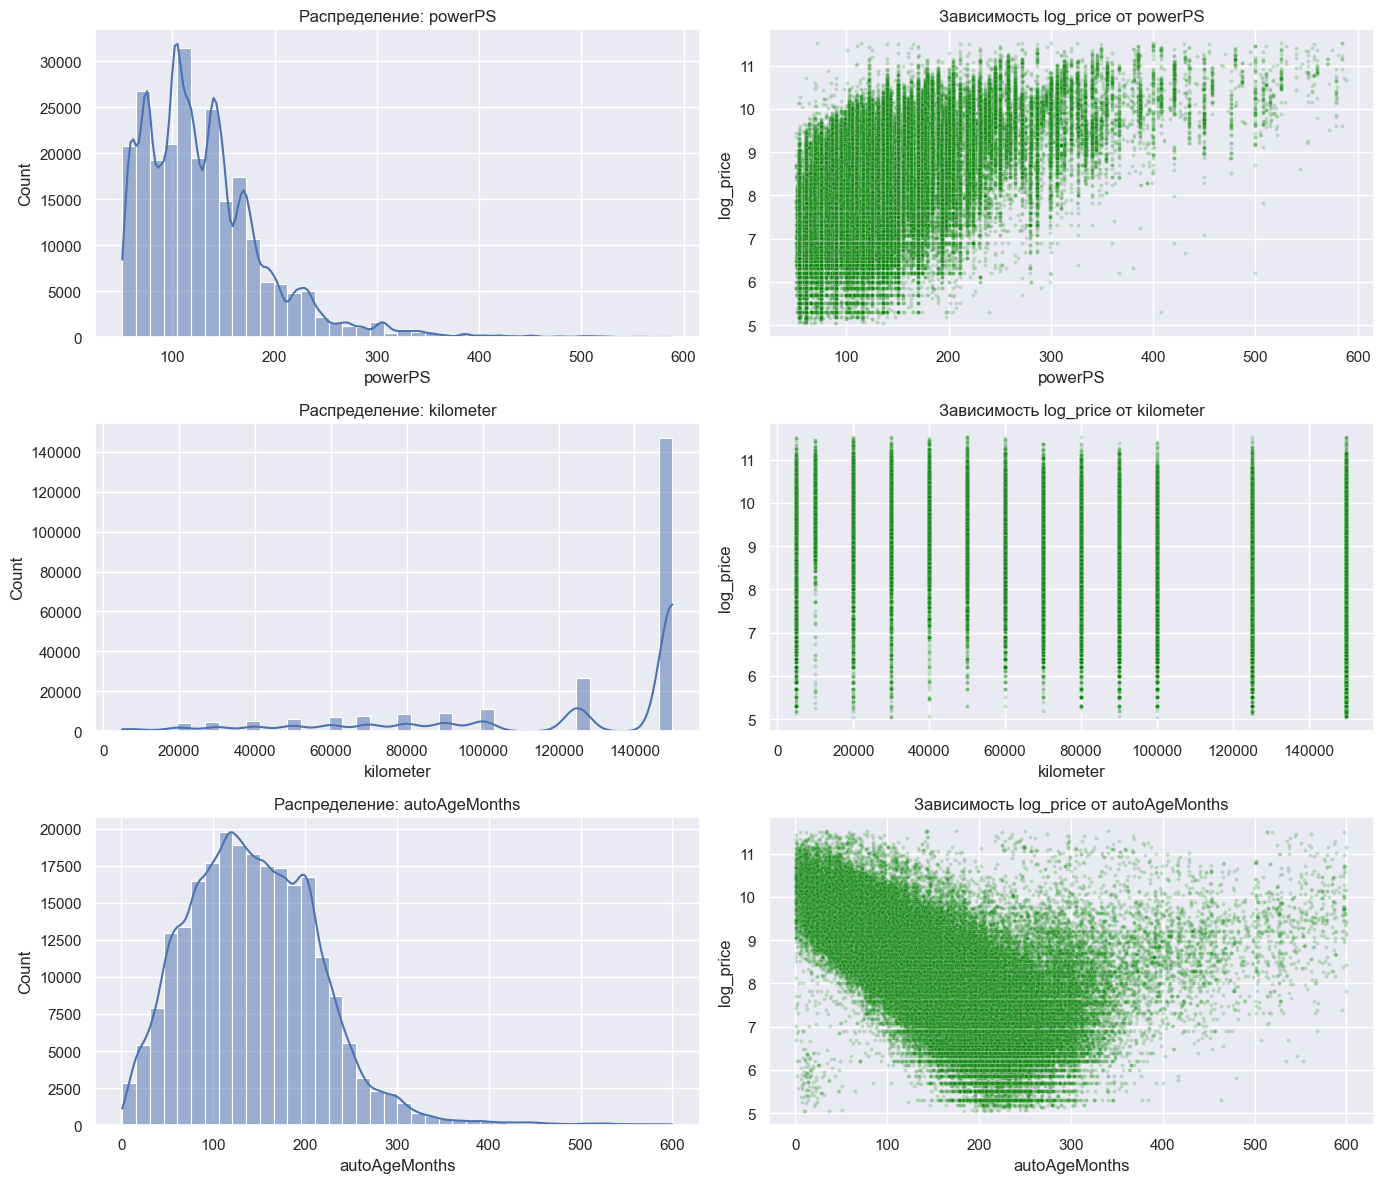

In [21]:
n = len(numeric)
fig, axes = plt.subplots(n, 2, figsize=(14, 4 * n))
for i, col in enumerate(numeric):
    sns.histplot(data=data, x=col, bins=40, ax=axes[i][0], kde=True)
    axes[i][0].set_title(f'Распределение: {col}')

    sns.scatterplot(data=data, x=col, y='log_price', s=8, alpha=0.2, ax=axes[i][1], color='green')
    axes[i][1].set_title(f'Зависимость log_price от {col}')
plt.tight_layout()
plt.show()


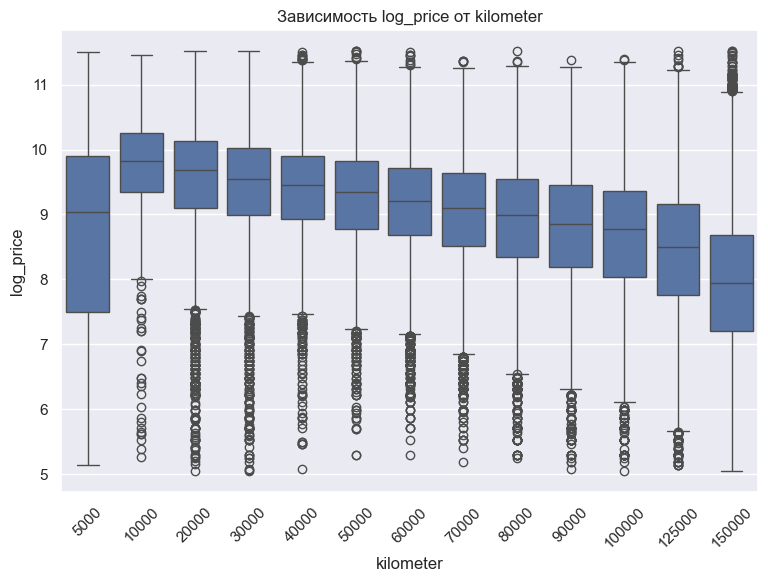

In [22]:
plt.figure(figsize = (9, 6))
sns.boxplot(x="kilometer", y="log_price", data=data)
plt.xticks(rotation=45)
plt.title('Зависимость log_price от kilometer')
plt.xlabel('kilometer')
plt.ylabel('log_price')
plt.show()


In [23]:
data['powerPS'].describe() #проверил, что нет нулевой мощности


count    240034.000000
mean        131.464468
std          60.631057
min          51.000000
25%          90.000000
50%         120.000000
75%         160.000000
max         589.000000
Name: powerPS, dtype: float64

['log_powerPS', 'kilometer', 'autoAgeMonths']

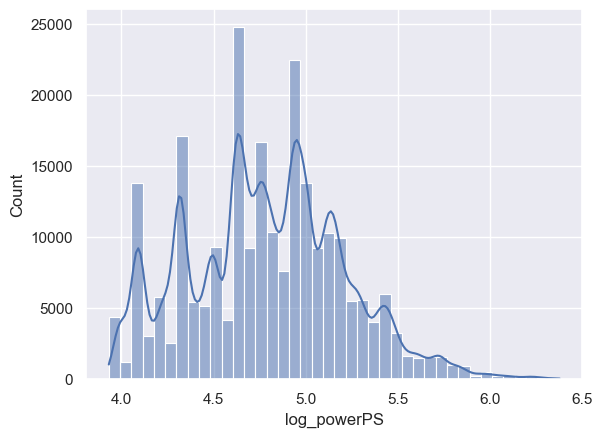

In [ ]:
data['log_powerPS'] = np.log(data['powerPS'])
data.drop('powerPS', axis=1, inplace=True)
sns.histplot(data=data, x='log_powerPS', bins=40, kde=True)
numeric[numeric.index('powerPS')] = 'log_powerPS'
numeric


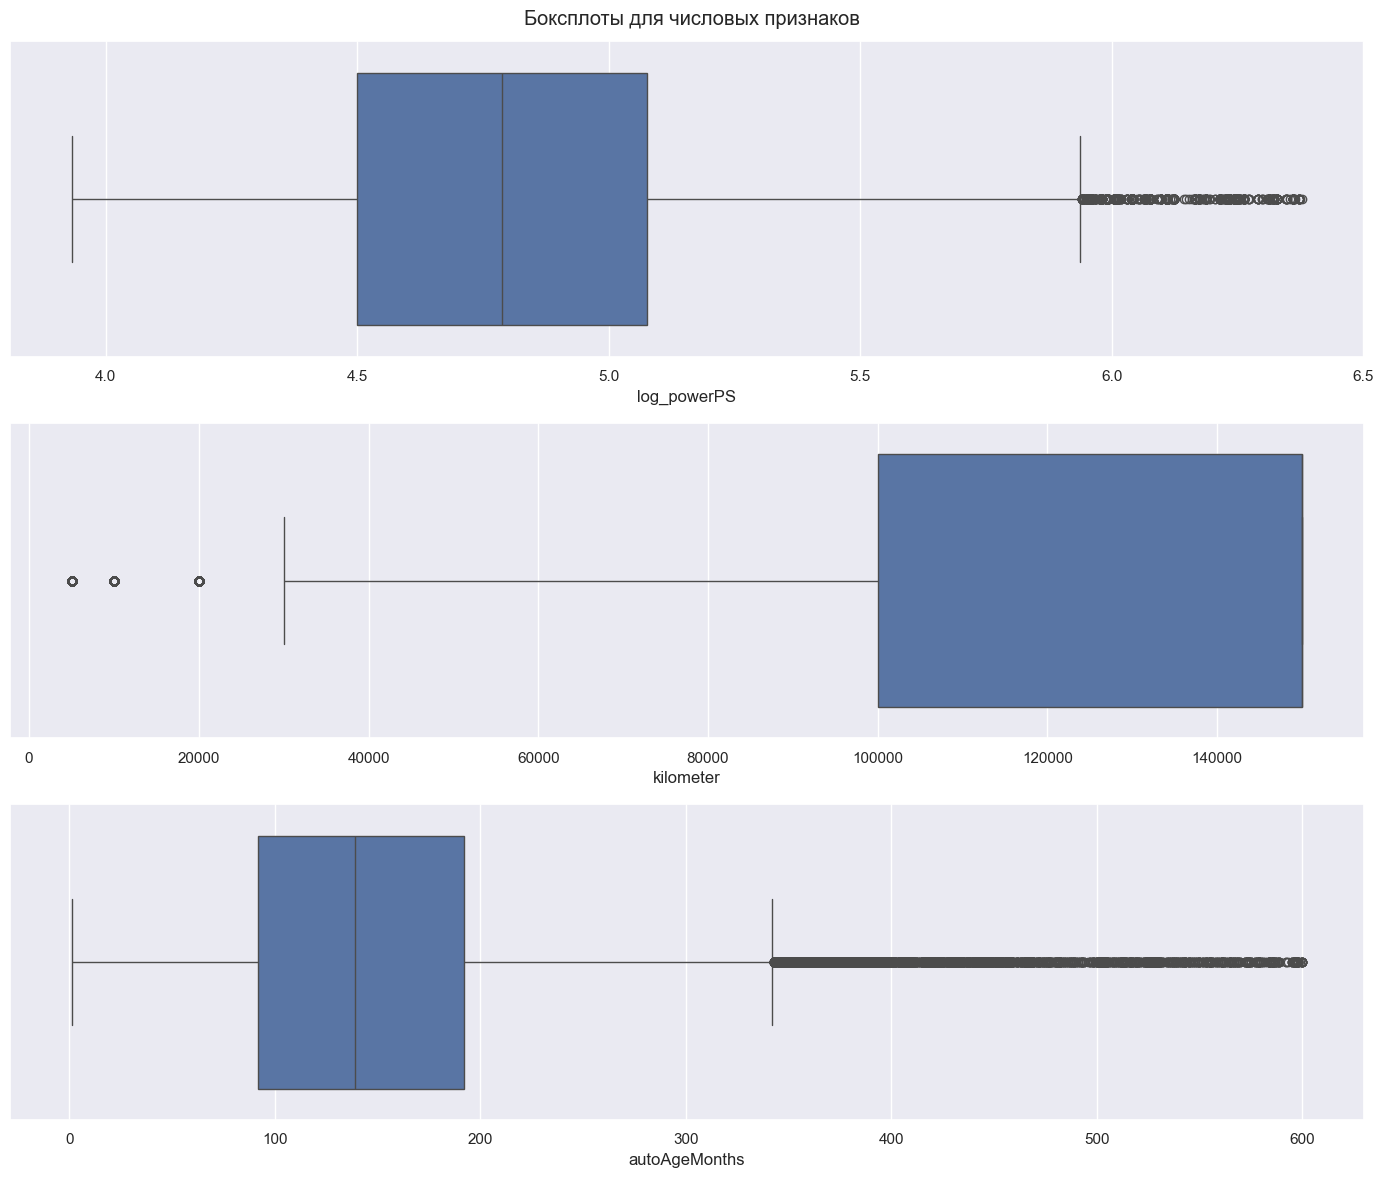

In [25]:
fig, axes = plt.subplots(n, 1, figsize=(14, 4 * n))
for i, col in enumerate(numeric):
    sns.boxplot(data=data, x=col, ax=axes[i])
    axes[i].set_xlabel(f'{col}')
plt.suptitle('Боксплоты для числовых признаков')
plt.tight_layout()
plt.show()


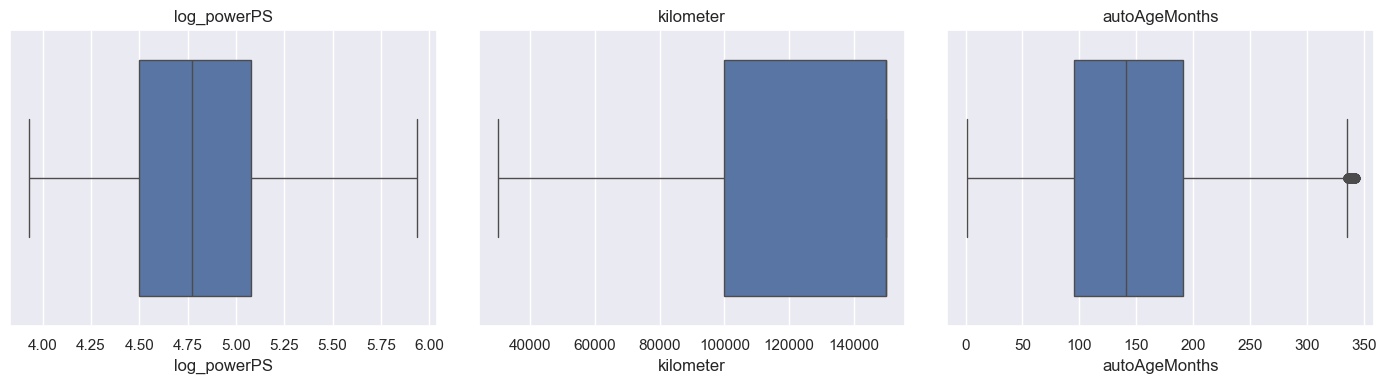

In [26]:
features = ['log_powerPS', 'kilometer', 'autoAgeMonths']

mask = pd.Series(True, index=data.index)

for col in features:
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    mask &= data[col].between(low, high)

data = data.loc[mask].copy()

fig, axes = plt.subplots(1, len(features), figsize=(14, 4))
for ax, col in zip(axes, features):
    sns.boxplot(x=data[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()


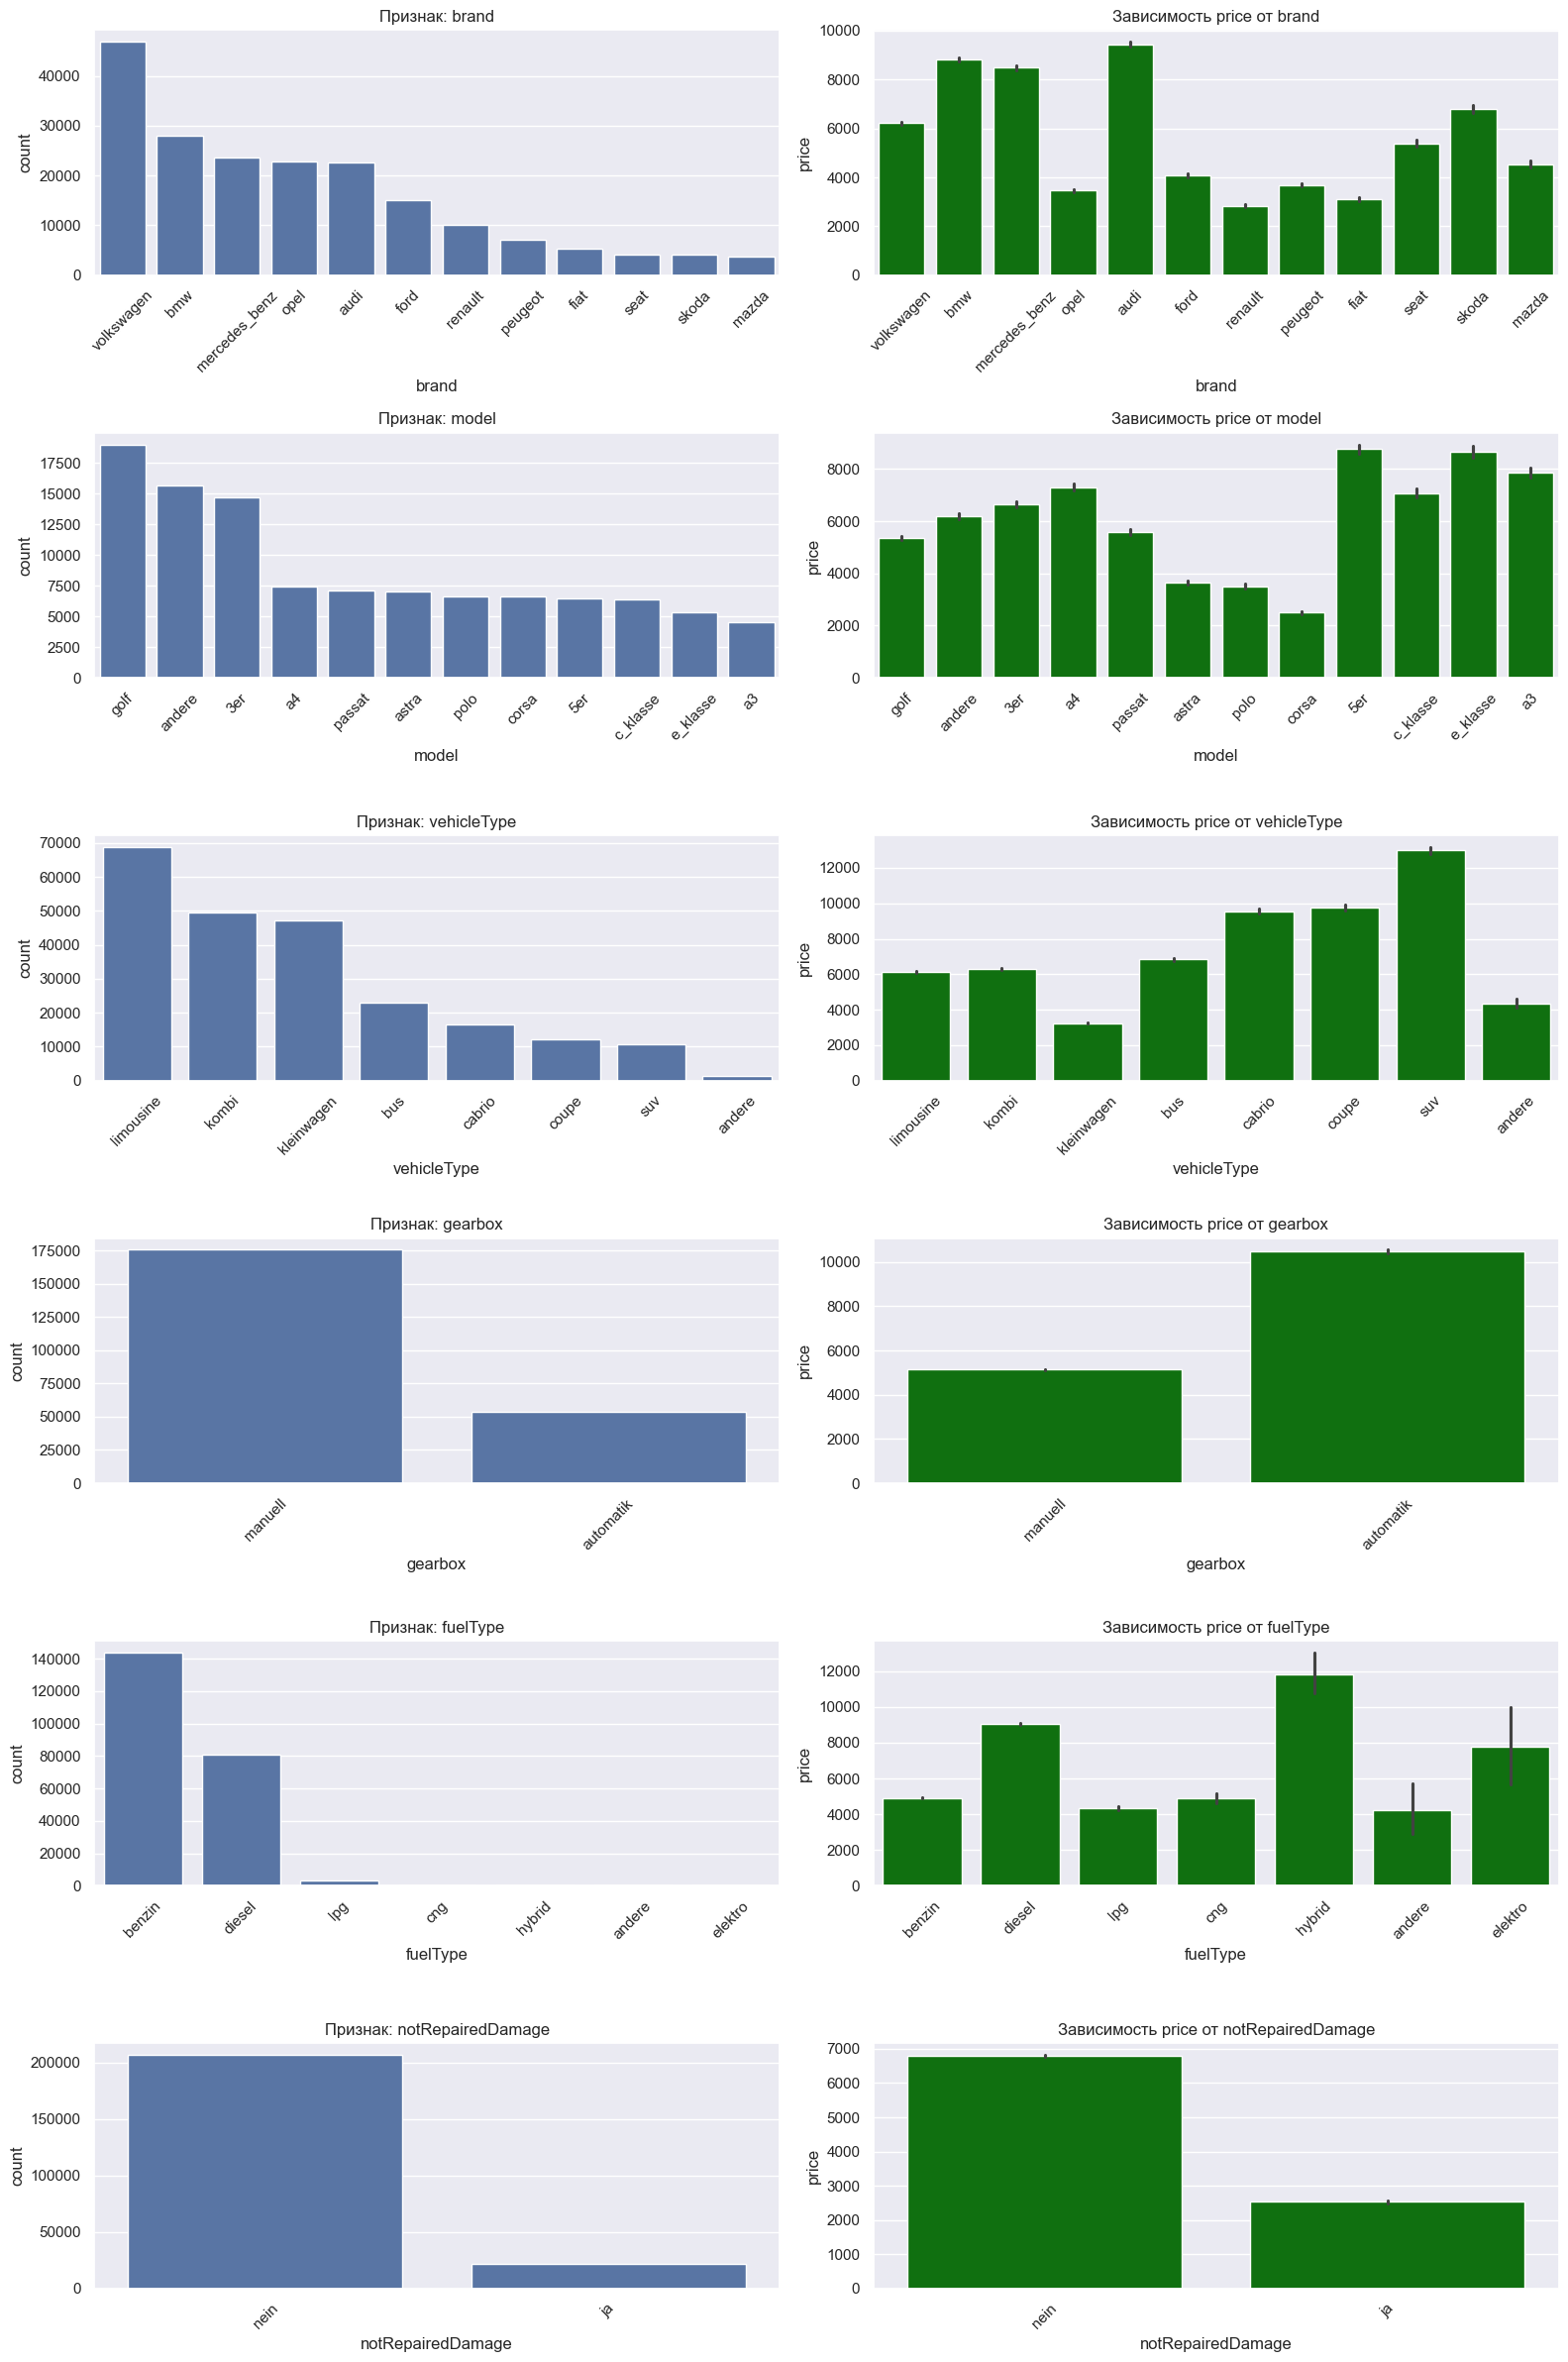

In [27]:
top_k = 12
m = len(categorical)
fig, axes = plt.subplots(m, 2, figsize=(16, 4 * m))
for i, col in enumerate(categorical):
    top = data[col].value_counts().head(top_k).index
    top_data = data[data[col].isin(top)]
    sns.countplot(data=top_data, x=col, order=top ,ax=axes[i][0])
    axes[i][0].set_title(f'Признак: {col}')
    axes[i][0].tick_params(axis='x', rotation=45)

    sns.barplot(data=top_data, x=col, y=np.e**top_data['log_price'], order=top, ax=axes[i][1], color='green')
    axes[i][1].set_ylabel('price')
    axes[i][1].set_title(f'Зависимость price от {col}')
    axes[i][1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [28]:
data.info()


<class 'pandas.DataFrame'>
Index: 228919 entries, 0 to 241189
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   brand              228919 non-null  str    
 1   model              228919 non-null  str    
 2   vehicleType        228919 non-null  str    
 3   gearbox            228919 non-null  str    
 4   fuelType           228919 non-null  str    
 5   notRepairedDamage  228919 non-null  str    
 6   kilometer          228919 non-null  int64  
 7   autoAgeMonths      228919 non-null  int64  
 8   log_price          228919 non-null  float64
 9   log_powerPS        228919 non-null  float64
dtypes: float64(2), int64(2), str(6)
memory usage: 19.2 MB


In [29]:
data['bias'] = 1
other += ['bias']

x = data[categorical + numeric + other]
y = data['log_price']


In [30]:
from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(x, y, test_size=0.1, random_state=10)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=1/9, random_state=10)


In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler


column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore'), categorical),
    ('scaling', StandardScaler(), numeric),
    ('other',  'passthrough', other)
])

X_train = column_transformer.fit_transform(X_train)
X_val = column_transformer.transform(X_val)
X_test = column_transformer.transform(X_test)


### Результаты блока

| Шаг | Наблюдение |
|---|---|
| `price` | Сильный правый хвост, поэтому используется `log_price` |
| `powerPS` | Также имеет длинный хвост, используется `log_powerPS` |
| `kilometer` | Видна отрицательная связь с ценой |
| `brand/model/vehicleType` | Категориальные признаки заметно влияют на цену |
| После очистки | 228,919 наблюдений перед train/val/test split |

Важно: split делается до fitting encoders/scalers, чтобы не протекала информация из validation/test.


## 4. Сравнение градиентных методов

Для каждого оптимизатора подбираю learning rate по validation MSE и сравниваю train/validation/test качество. Это показывает не только итоговую ошибку, но и устойчивость разных методов оптимизации.


In [32]:
y_train = y_train.to_numpy()
y_val = y_val.to_numpy()
y_test = y_test.to_numpy()


In [33]:
from sklearn.metrics import r2_score

grid = {
    "VanillaGradientDescent": np.logspace(-3, 1, 10),
    "Adam": np.logspace(-5, -0.5, 10),
    "StochasticGradientDescent": np.logspace(-4, 0.5, 10),
    "MomentumDescent": np.logspace(-4, 0.5, 10),
    "SAGDescent": np.logspace(-4, 0, 10)
}

mse_loss_history = {}
mse_params_history = {}

for descent_model in descent_models:
    best_val_loss = float("inf")
    best_lambda = None
    best_loss_history = None
    num_iter = 0
    best_train_mse = None
    best_test_mse = None
    best_train_r2 = None
    best_test_r2 = None
    best_val_r2 = None
    for lambd in grid[descent_model.__name__]:
        optimizer = descent_model(lr_schedule=TimeDecayLR(lambda_=lambd))
        model = CustomLinearRegression(optimizer=optimizer)
        model.fit(X_train, y_train)

        val_loss = model.compute_loss(X_val, y_val)
        if np.isfinite(val_loss) and val_loss < best_val_loss:
            train_mse = model.compute_loss(X_train, y_train)
            test_mse = model.compute_loss(X_test, y_test)

            y_train_pred = model.predict(X_train)
            y_val_pred = model.predict(X_val)
            y_test_pred = model.predict(X_test)

            train_r2 = r2_score(y_train, y_train_pred)
            val_r2 = r2_score(y_val, y_val_pred)
            test_r2 = r2_score(y_test, y_test_pred)

            best_val_loss = val_loss
            best_lambda = lambd
            num_iter = optimizer.iteration
            best_loss_history = model.loss_history.copy()

            best_train_mse = train_mse
            best_test_mse = test_mse
            best_train_r2 = train_r2
            best_val_r2 = val_r2
            best_test_r2 = test_r2

    mse_loss_history[descent_model.__name__] = best_loss_history
    mse_params_history[descent_model.__name__] = {
        "lambda": best_lambda,
        "val_mse": best_val_loss,
        "train_mse": best_train_mse,
        "test_mse": best_test_mse,
        "train_r2": best_train_r2,
        "val_r2": best_val_r2,
        "test_r2": best_test_r2,
        "iterations": num_iter,
    }

    print(f"Модель: {descent_model.__name__}")
    print(f"\tЛямбда: {best_lambda}")
    print(
        f"\tMSE train | val | test: {best_train_mse:.6f} | {best_val_loss:.6f} | {best_test_mse:.6f}"
    )
    print(
        f"\tR2 train | val | test: {best_train_r2:.6f} | {best_val_r2:.6f} | {best_test_r2:.6f}"
    )
    print(f"\tИтераций: {num_iter}")


Модель: VanillaGradientDescent
	Лямбда: 1.2915496650148828
	MSE train | val | test: 0.199361 | 0.199278 | 0.203880
	R2 train | val | test: 0.828386 | 0.829006 | 0.823530
	Итераций: 389
Модель: StochasticGradientDescent
	Лямбда: 0.31622776601683794
	MSE train | val | test: 0.223636 | 0.223814 | 0.226605
	R2 train | val | test: 0.807489 | 0.807953 | 0.803860
	Итераций: 1000
Модель: SAGDescent
	Лямбда: 1.0
	MSE train | val | test: 0.497589 | 0.495138 | 0.500608
	R2 train | val | test: 0.571664 | 0.575138 | 0.566694
	Итераций: 1000
Модель: MomentumDescent
	Лямбда: 1.0
	MSE train | val | test: 0.184233 | 0.184445 | 0.189547
	R2 train | val | test: 0.841408 | 0.841734 | 0.835936
	Итераций: 634
Модель: Adam
	Лямбда: 0.31622776601683794
	MSE train | val | test: 0.181158 | 0.181674 | 0.186419
	R2 train | val | test: 0.844055 | 0.844111 | 0.838644
	Итераций: 1000


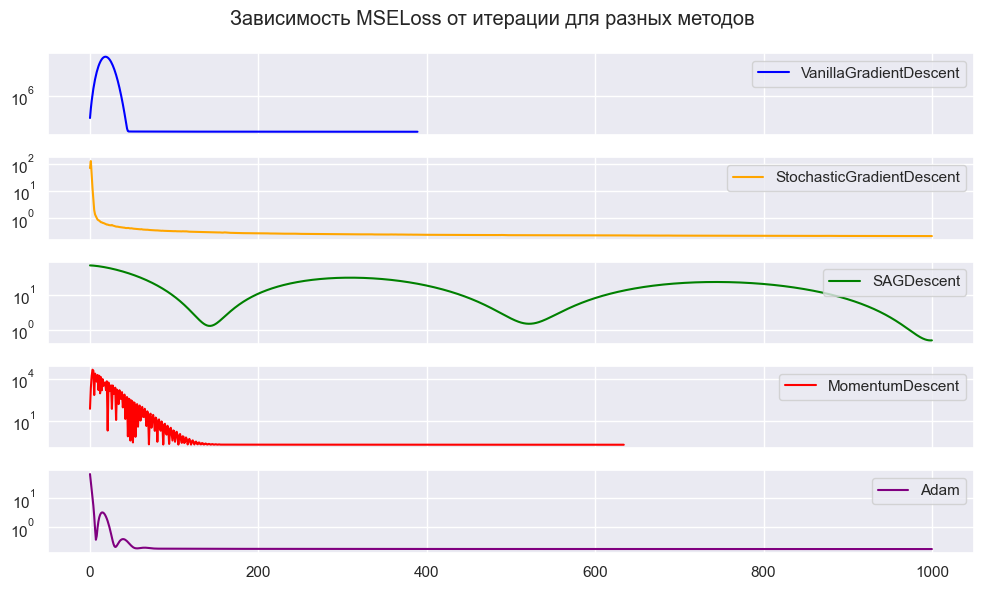

In [34]:
fig, axes = plt.subplots(len(mse_loss_history), 1, figsize=(10, 6), sharex=True)
colors = ['blue', 'orange', 'green', 'red', 'purple']
for i, (model_name, function_loss_history) in enumerate(mse_loss_history.items()):
    axes[i].plot(function_loss_history, label=model_name, color=colors[i])
    axes[i].set_yscale('log')
    axes[i].legend(loc='upper right')
plt.suptitle('Зависимость MSELoss от итерации для разных методов')
plt.tight_layout()
plt.show()


In [35]:
batch_grid = [1024, 2048, 4096]

best_val_loss_SAG = float("inf")
best_lambda_SAG = None
best_batch_SAG = None
best_loss_history_SAG = None
num_iter_SAG = 0
best_train_mse_SAG = None
best_test_mse_SAG = None
best_train_r2_SAG = None
best_test_r2_SAG = None
best_val_r2_SAG = None

for batch in batch_grid:
    for lambd in grid["SAGDescent"]:
        optimizer = SAGDescent(batch_size=batch, lr_schedule=TimeDecayLR(lambda_=lambd))
        model = CustomLinearRegression(optimizer=optimizer)
        model.fit(X_train, y_train)

        val_loss = model.compute_loss(X_val, y_val)
        if np.isfinite(val_loss) and val_loss < best_val_loss_SAG:
            train_mse = model.compute_loss(X_train, y_train)
            test_mse = model.compute_loss(X_test, y_test)

            y_train_pred = model.predict(X_train)
            y_val_pred = model.predict(X_val)
            y_test_pred = model.predict(X_test)

            train_r2 = r2_score(y_train, y_train_pred)
            val_r2 = r2_score(y_val, y_val_pred)
            test_r2 = r2_score(y_test, y_test_pred)

            best_val_loss_SAG = val_loss
            best_lambda_SAG = lambd
            num_iter_SAG = optimizer.iteration
            best_loss_history_SAG = model.loss_history.copy()
            best_train_mse_SAG = train_mse
            best_test_mse_SAG = test_mse
            best_train_r2_SAG = train_r2
            best_val_r2_SAG = val_r2
            best_test_r2_SAG = test_r2
            best_batch_SAG = batch


In [36]:
mse_loss_history["SAGDescent"] = best_loss_history_SAG
mse_params_history["SAGDescent"] = {
    "lambda": best_lambda_SAG,
    "val_mse": best_val_loss_SAG,
    "train_mse": best_train_mse_SAG,
    "test_mse": best_test_mse_SAG,
    "train_r2": best_train_r2_SAG,
    "val_r2": best_val_r2_SAG,
    "test_r2": best_test_r2_SAG,
    "iterations": num_iter_SAG,
    "batch_size": best_batch_SAG,
}
print("Модель: SAGDescent")
print(f"\tЛямбда: {best_lambda_SAG}")
print(f"\tMSE train | val | test: {best_train_mse_SAG:.6f} | {best_val_loss_SAG:.6f} | {best_test_mse_SAG:.6f}")
print(f"\tR2 train | val | test: {best_train_r2_SAG:.6f} | {best_val_r2_SAG:.6f} | {best_test_r2_SAG:.6f}")
print(f"\tИтераций: {num_iter_SAG}")
print(f"\tРазмер батча: {best_batch_SAG}")


Модель: SAGDescent
	Лямбда: 1.0
	MSE train | val | test: 0.204326 | 0.204163 | 0.208579
	R2 train | val | test: 0.824112 | 0.824814 | 0.819463
	Итераций: 485
	Размер батча: 4096


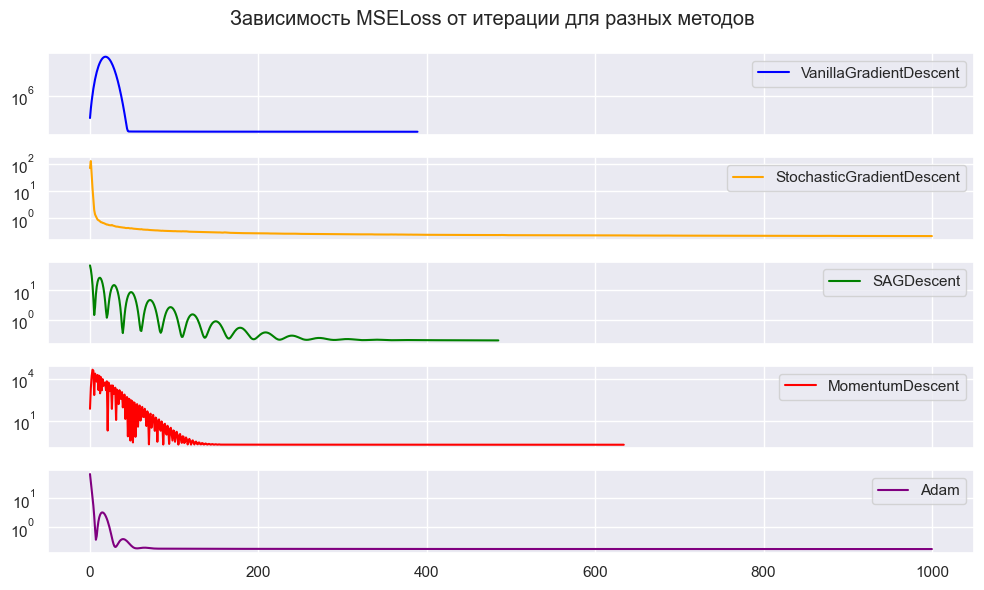

In [37]:
fig, axes = plt.subplots(len(mse_loss_history), 1, figsize=(10, 6), sharex=True)
colors = ['blue', 'orange', 'green', 'red', 'purple']
for i, (model_name, function_loss_history) in enumerate(mse_loss_history.items()):
    axes[i].plot(function_loss_history, label=model_name, color=colors[i])
    axes[i].set_yscale('log')
    axes[i].legend(loc='upper right')
plt.suptitle('Зависимость MSELoss от итерации для разных методов')
plt.tight_layout()
plt.show()


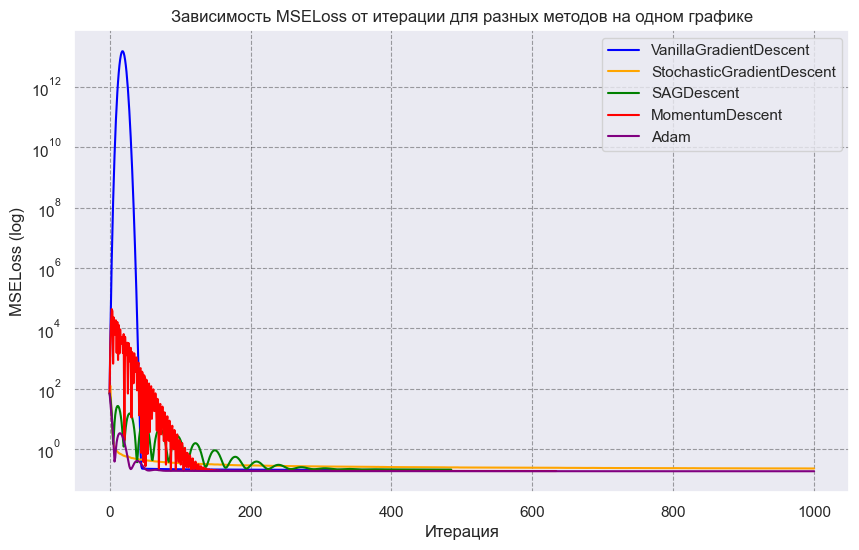

In [38]:
plt.figure(figsize=(10, 6))
for i, (model_name, function_loss_history) in enumerate(mse_loss_history.items()):
    plt.plot(function_loss_history, label=model_name, color=colors[i])
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('Зависимость MSELoss от итерации для разных методов на одном графике')
plt.xlabel('Итерация')
plt.ylabel('MSELoss (log)')
plt.grid(True, which='both', color='black', alpha=0.35, linewidth=0.8, linestyle='--')
plt.show()


### Результаты блока

| Optimizer | Test MSE | Test R2 | Iterations |
|---|---:|---:|---:|
| Vanilla GD | 0.2039 | 0.8235 | 389 |
| SGD | 0.2266 | 0.8039 | 1000 |
| SAG | 0.2086 | 0.8195 | 485 |
| Momentum | 0.1895 | 0.8359 | 634 |
| Adam | 0.1864 | 0.8386 | 1000 |

Вывод: Adam и Momentum дали лучшее качество среди реализованных методов. Vanilla GD сходится стабильно, но хуже по test MSE; SGD сильнее зависит от batch size и шума градиента.


## 5. Влияние batch size на SGD

Здесь отдельно проверяю компромисс между шумом стохастического градиента и стоимостью одной итерации. Batch size перебирается от очень маленьких значений до почти full-batch режима.


In [39]:
X_train.shape


(183135, 307)

In [40]:
import time
from sklearn.metrics import r2_score

batch_grid = [1, 4, 16, 64, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536]

best_hist_by_batch = {}
best_val_by_batch = {}
avg_times = []
avg_iters = []

global_best_val_loss = float("inf")
SAG_lambda = mse_params_history['StochasticGradientDescent']['lambda']

for batch in batch_grid:
    times_batch = []
    iters_batch = []

    batch_best_val_loss = float("inf")
    batch_best_history = None
    
    for k in range(10):
        np.random.seed(k)
        optimizer = StochasticGradientDescent(
            lr_schedule=TimeDecayLR(lambda_=SAG_lambda),
            batch_size=batch
        )
        model = CustomLinearRegression(optimizer=optimizer)

        t0 = time.perf_counter()
        model.fit(X_train, y_train)
        t1 = time.perf_counter()

        val_loss = model.compute_loss(X_val, y_val)
        times_batch.append(t1 - t0)
        iters_batch.append(optimizer.iteration)
        if np.isfinite(val_loss) and val_loss < batch_best_val_loss:
            batch_best_val_loss = val_loss
            batch_best_history = model.loss_history.copy()
            
            if val_loss < global_best_val_loss:
                global_best_val_loss = val_loss
                
                y_train_pred = model.predict(X_train)
                y_val_pred = model.predict(X_val)
                y_test_pred = model.predict(X_test)
                
                mse_params_history["StochasticGradientDescent"] = {
                    "lambda": SAG_lambda,
                    "val_mse": val_loss,
                    "train_mse": model.compute_loss(X_train, y_train),
                    "test_mse": model.compute_loss(X_test, y_test),
                    "train_r2": r2_score(y_train, y_train_pred),
                    "val_r2": r2_score(y_val, y_val_pred),
                    "test_r2": r2_score(y_test, y_test_pred),
                    "iterations": optimizer.iteration,
                    "batch_size": batch,
                }
                mse_loss_history["StochasticGradientDescent"] = batch_best_history

    avg_times.append(np.mean(times_batch))
    avg_iters.append(np.mean(iters_batch))
    
    best_hist_by_batch[batch] = batch_best_history
    best_val_by_batch[batch] = batch_best_val_loss

    print(f"batch={batch} | val_loss={batch_best_val_loss} | mean_time={np.mean(times_batch):.3f}s | mean_iters={np.mean(iters_batch):.1f}")


batch=1 | val_loss=1.1421045984939016 | mean_time=0.273s | mean_iters=404.0
batch=4 | val_loss=0.2485393321328967 | mean_time=0.646s | mean_iters=974.2
batch=16 | val_loss=0.22278515727558157 | mean_time=0.669s | mean_iters=1000.0
batch=64 | val_loss=0.21584534213887469 | mean_time=0.677s | mean_iters=1000.0
batch=256 | val_loss=0.21361440390413183 | mean_time=0.686s | mean_iters=993.6
batch=512 | val_loss=0.21891419232486176 | mean_time=0.477s | mean_iters=681.3
batch=1024 | val_loss=0.22237619800931677 | mean_time=0.353s | mean_iters=489.5
batch=2048 | val_loss=0.22534044239815088 | mean_time=0.299s | mean_iters=395.6
batch=4096 | val_loss=0.22785605942109197 | mean_time=0.291s | mean_iters=360.2
batch=8192 | val_loss=0.2293159780283581 | mean_time=0.314s | mean_iters=340.5
batch=16384 | val_loss=0.2295161464225168 | mean_time=0.385s | mean_iters=330.5
batch=32768 | val_loss=0.22983918859957767 | mean_time=0.560s | mean_iters=327.5
batch=65536 | val_loss=0.23017485682210834 | mean_ti

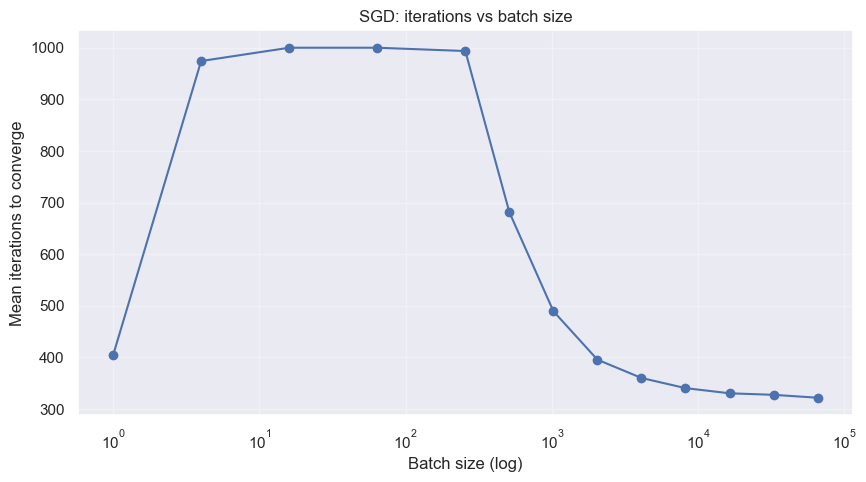

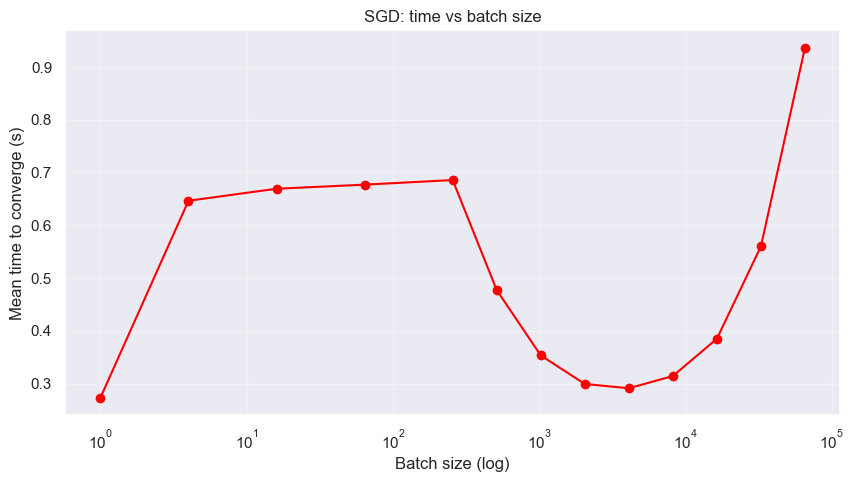

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(batch_grid, avg_iters, marker='o')
plt.xscale('log')
plt.xlabel('Размер batch (log)')
plt.ylabel('Среднее кол-во итераций')
plt.title('SGD: итерации и размер batch')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(batch_grid, avg_times, marker='o', color='red')
plt.xscale('log')
plt.xlabel('Размер batch (log)')
plt.ylabel('Среднее время(s)')
plt.title('SGD: время и размер batch')
plt.grid(True, alpha=0.3)
plt.show()


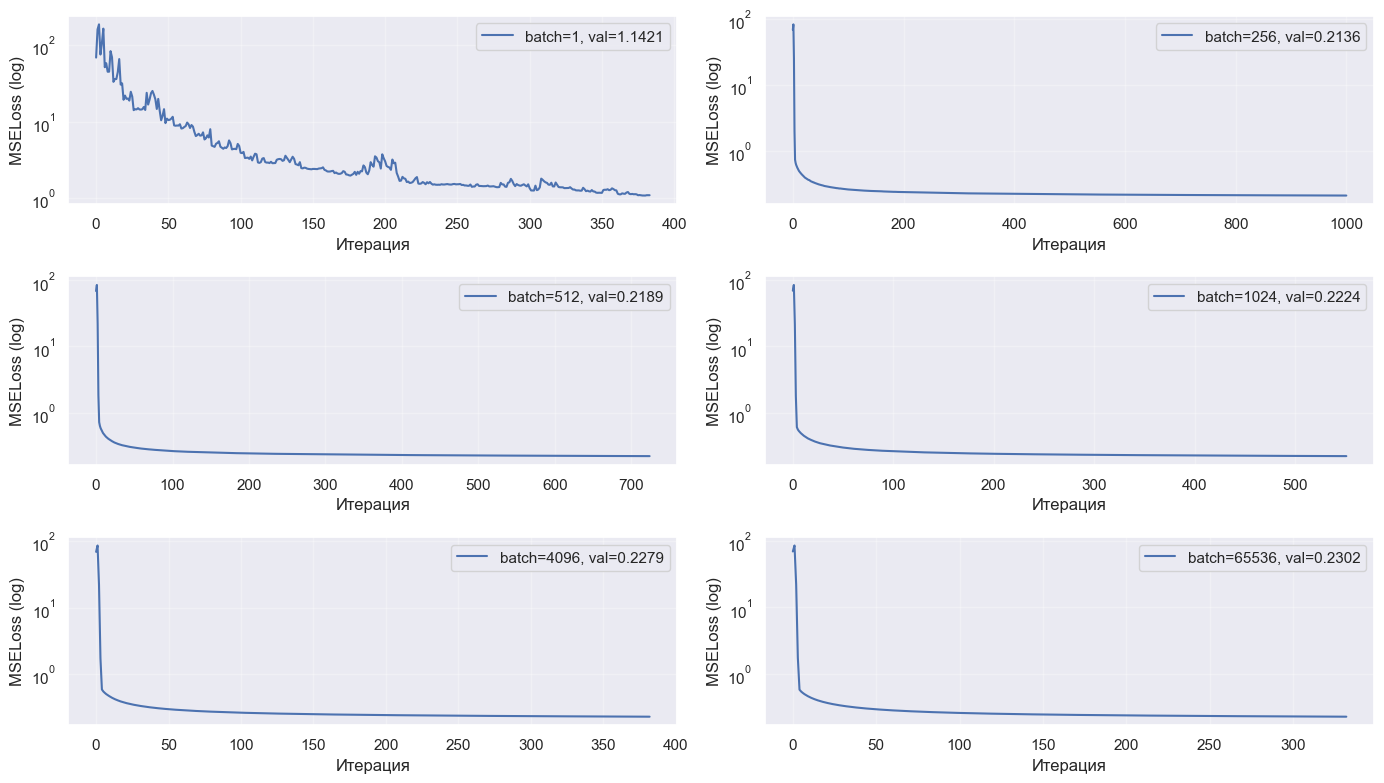

In [42]:
show_batches = [1, 256, 512, 1024, 4096, 65536]

fig, axes = plt.subplots(3, 2, figsize=(14, 8))
axes = np.array(axes).reshape(-1)
for i, b in enumerate(show_batches):
    axes[i].plot(best_hist_by_batch.get(b), label=f'batch={b}, val={best_val_by_batch[b]:.4f}')
    axes[i].set_yscale('log')
    axes[i].set_xlabel('Итерация')
    axes[i].set_ylabel('MSELoss (log)')
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()

plt.tight_layout()
plt.show()


### Результаты блока

SGD начинает стабильно сходиться при batch size больше `64`. Маленькие batch size дают слишком шумный градиент и плохой validation loss, а большие batch size уменьшают шум, но приближают метод к full-batch GD и делают шаг дороже.


## 6. L2-регуляризация

Проверяю, как L2 влияет на разные оптимизаторы. Регуляризация добавлена как wrapper над основной loss-функцией, поэтому её можно комбинировать с разными методами оптимизации.


In [43]:
from linear_models_gd import L2Regularization


In [44]:
mu_grid = np.logspace(-3, 2, 10)

reg_loss_history = {}
reg_params_history = {}

for descent_model in descent_models:
    best_val_full_loss = float("inf")
    best_lambda = None
    best_mu = None
    best_loss_history = None
    num_iter = 0
    results = {}

    saved_batch = mse_params_history.get(descent_model.__name__, {}).get("batch_size", 32)
    current_lr_grid = grid[descent_model.__name__] 
    
    for lambd in current_lr_grid:
        for mu in mu_grid:
            if descent_model.__name__ in ["StochasticGradientDescent", "SAGDescent"]:
                optimizer = descent_model(batch_size=saved_batch, lr_schedule=TimeDecayLR(lambda_=lambd))
            else:
                optimizer = descent_model(lr_schedule=TimeDecayLR(lambda_=lambd))
                
            model = CustomLinearRegression(optimizer=optimizer, loss_function=L2Regularization(core_loss=MSELoss(), mu_rate=mu))
            model.fit(X_train, y_train)
            if not np.all(np.isfinite(model.w)):
                continue

            val_full_loss = model.compute_loss(X_val, y_val)
            if np.isfinite(val_full_loss) and val_full_loss < best_val_full_loss:
                best_val_full_loss = val_full_loss
                best_lambda = lambd
                best_mu = mu
                num_iter = optimizer.iteration
                best_loss_history = model.loss_history.copy()

                best_train_mse = MSELoss().loss(X_train, y_train, model.w)
                best_val_mse = MSELoss().loss(X_val, y_val, model.w)
                best_test_mse = MSELoss().loss(X_test, y_test, model.w)

                results = {
                    "train_mse": best_train_mse,
                    "val_mse": best_val_mse,
                    "test_mse": best_test_mse,
                    "train_r2": r2_score(y_train, model.predict(X_train)),
                    "val_r2": r2_score(y_val, model.predict(X_val)),
                    "test_r2": r2_score(y_test, model.predict(X_test))
                }

    reg_loss_history[descent_model.__name__] = best_loss_history
    reg_params_history[descent_model.__name__] = {
        "lambda": best_lambda,
        "mu": best_mu,
        "iterations": num_iter,
        **results
    }

print("L2 Regularization Results (Pure MSE):")
for model_name, params in reg_params_history.items():
    print(f"Модель: {model_name}")
    print(f"\tЛямбда: {params['lambda']} | Му: {params['mu']}")
    print(f"\tMSE train|val|test: {params['train_mse']:.6f}|{params['val_mse']:.6f}|{params['test_mse']:.6f}")
    print(f"\tR2 train|val|test: {params['train_r2']:.6f}|{params['val_r2']:.6f}|{params['test_r2']:.6f}")


L2 Regularization Results (Pure MSE):
Модель: VanillaGradientDescent
	Лямбда: 1.2915496650148828 | Му: 0.001
	MSE train|val|test: 0.199765|0.199660|0.204238
	R2 train|val|test: 0.828037|0.828678|0.823220
Модель: StochasticGradientDescent
	Лямбда: 0.31622776601683794 | Му: 0.001
	MSE train|val|test: 0.215842|0.215268|0.219939
	R2 train|val|test: 0.814198|0.815285|0.809630
Модель: SAGDescent
	Лямбда: 1.0 | Му: 0.001
	MSE train|val|test: 0.204403|0.204208|0.208634
	R2 train|val|test: 0.824045|0.824776|0.819416
Модель: MomentumDescent
	Лямбда: 1.0 | Му: 0.001
	MSE train|val|test: 0.185277|0.185333|0.190488
	R2 train|val|test: 0.840509|0.840971|0.835122
Модель: Adam
	Лямбда: 0.31622776601683794 | Му: 0.001
	MSE train|val|test: 0.186388|0.186922|0.192222
	R2 train|val|test: 0.839553|0.839608|0.833621


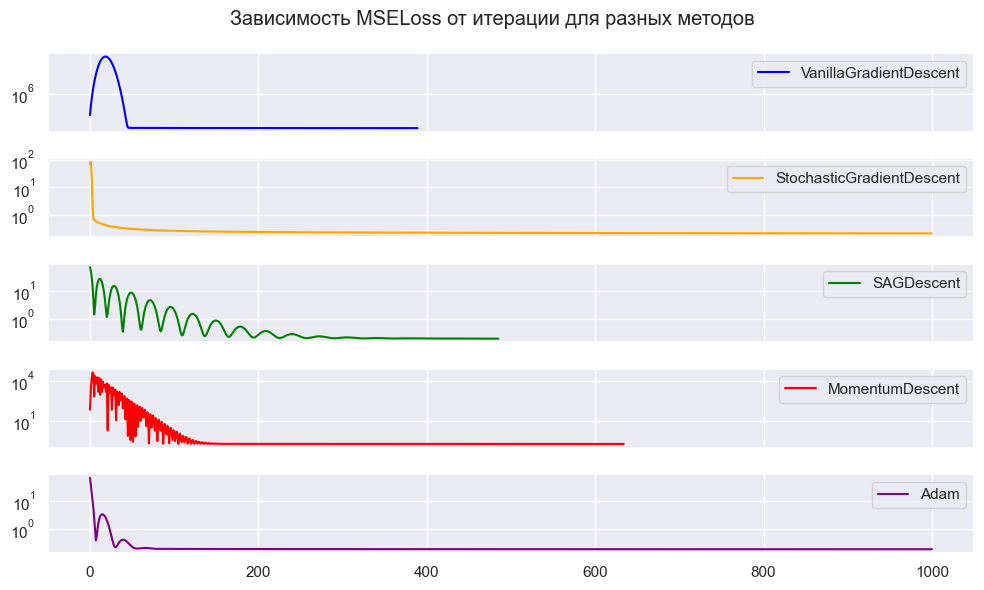

In [45]:
fig, axes = plt.subplots(len(mse_loss_history), 1, figsize=(10, 6), sharex=True)
colors = ['blue', 'orange', 'green', 'red', 'purple']
for i, (model_name, function_loss_history) in enumerate(mse_loss_history.items()):
    axes[i].plot(function_loss_history, label=model_name, color=colors[i])
    axes[i].set_yscale('log')
    axes[i].legend(loc='upper right')
plt.suptitle('Зависимость MSELoss от итерации для разных методов')
plt.tight_layout()
plt.show()


In [46]:
rows = []
for m in descent_models:
    name = m.__name__
    no = mse_params_history[name]
    rg = reg_params_history[name]

    rows.append({
        "Model": name, "reg": "no", "lambda": no["lambda"], "val_mse": no["val_mse"],
        "train_mse": no["train_mse"], "test_mse": no["test_mse"],
        "train_r2": no["train_r2"], "val_r2": no["val_r2"], "test_r2": no["test_r2"],
        "iters": no["iterations"], "mu": None
    })
    rows.append({
        "Model": name, "reg": "L2", "lambda": rg["lambda"], "val_mse": rg["val_mse"],
        "train_mse": rg["train_mse"], "test_mse": rg["test_mse"],
        "train_r2": rg["train_r2"], "val_r2": rg["val_r2"], "test_r2": rg["test_r2"],
        "iters": rg["iterations"], "mu": rg["mu"]
    })

df = pd.DataFrame(rows)

display(
    df.style
      .format({
          "lambda": "{:.6f}",
          "val_mse": "{:.6f}", "train_mse": "{:.6f}", "test_mse": "{:.6f}",
          "train_r2": "{:.6f}", "val_r2": "{:.6f}", "test_r2": "{:.6f}",
          "iters": "{:d}",
          "mu": lambda x: "-" if pd.isna(x) else f"{x:.2e}",
      })
      .hide(axis="index")
)


Model,reg,lambda,val_mse,train_mse,test_mse,train_r2,val_r2,test_r2,iters,mu
VanillaGradientDescent,no,1.291550,0.199278,0.199361,0.203880,0.828386,0.829006,0.823530,389,-
VanillaGradientDescent,L2,1.291550,0.199660,0.199765,0.204238,0.828037,0.828678,0.823220,379,1.00e-03
StochasticGradientDescent,no,0.316228,0.213614,0.214116,0.218046,0.815684,0.816704,0.811268,1000,-
StochasticGradientDescent,L2,0.316228,0.215268,0.215842,0.219939,0.814198,0.815285,0.809630,1000,1.00e-03
SAGDescent,no,1.000000,0.204163,0.204326,0.208579,0.824112,0.824814,0.819463,485,-
SAGDescent,L2,1.000000,0.204208,0.204403,0.208634,0.824045,0.824776,0.819416,484,1.00e-03
MomentumDescent,no,1.000000,0.184445,0.184233,0.189547,0.841408,0.841734,0.835936,634,-
MomentumDescent,L2,1.000000,0.185333,0.185277,0.190488,0.840509,0.840971,0.835122,663,1.00e-03
Adam,no,0.316228,0.181674,0.181158,0.186419,0.844055,0.844111,0.838644,1000,-
Adam,L2,0.316228,0.186922,0.186388,0.192222,0.839553,0.839608,0.833621,1000,1.00e-03


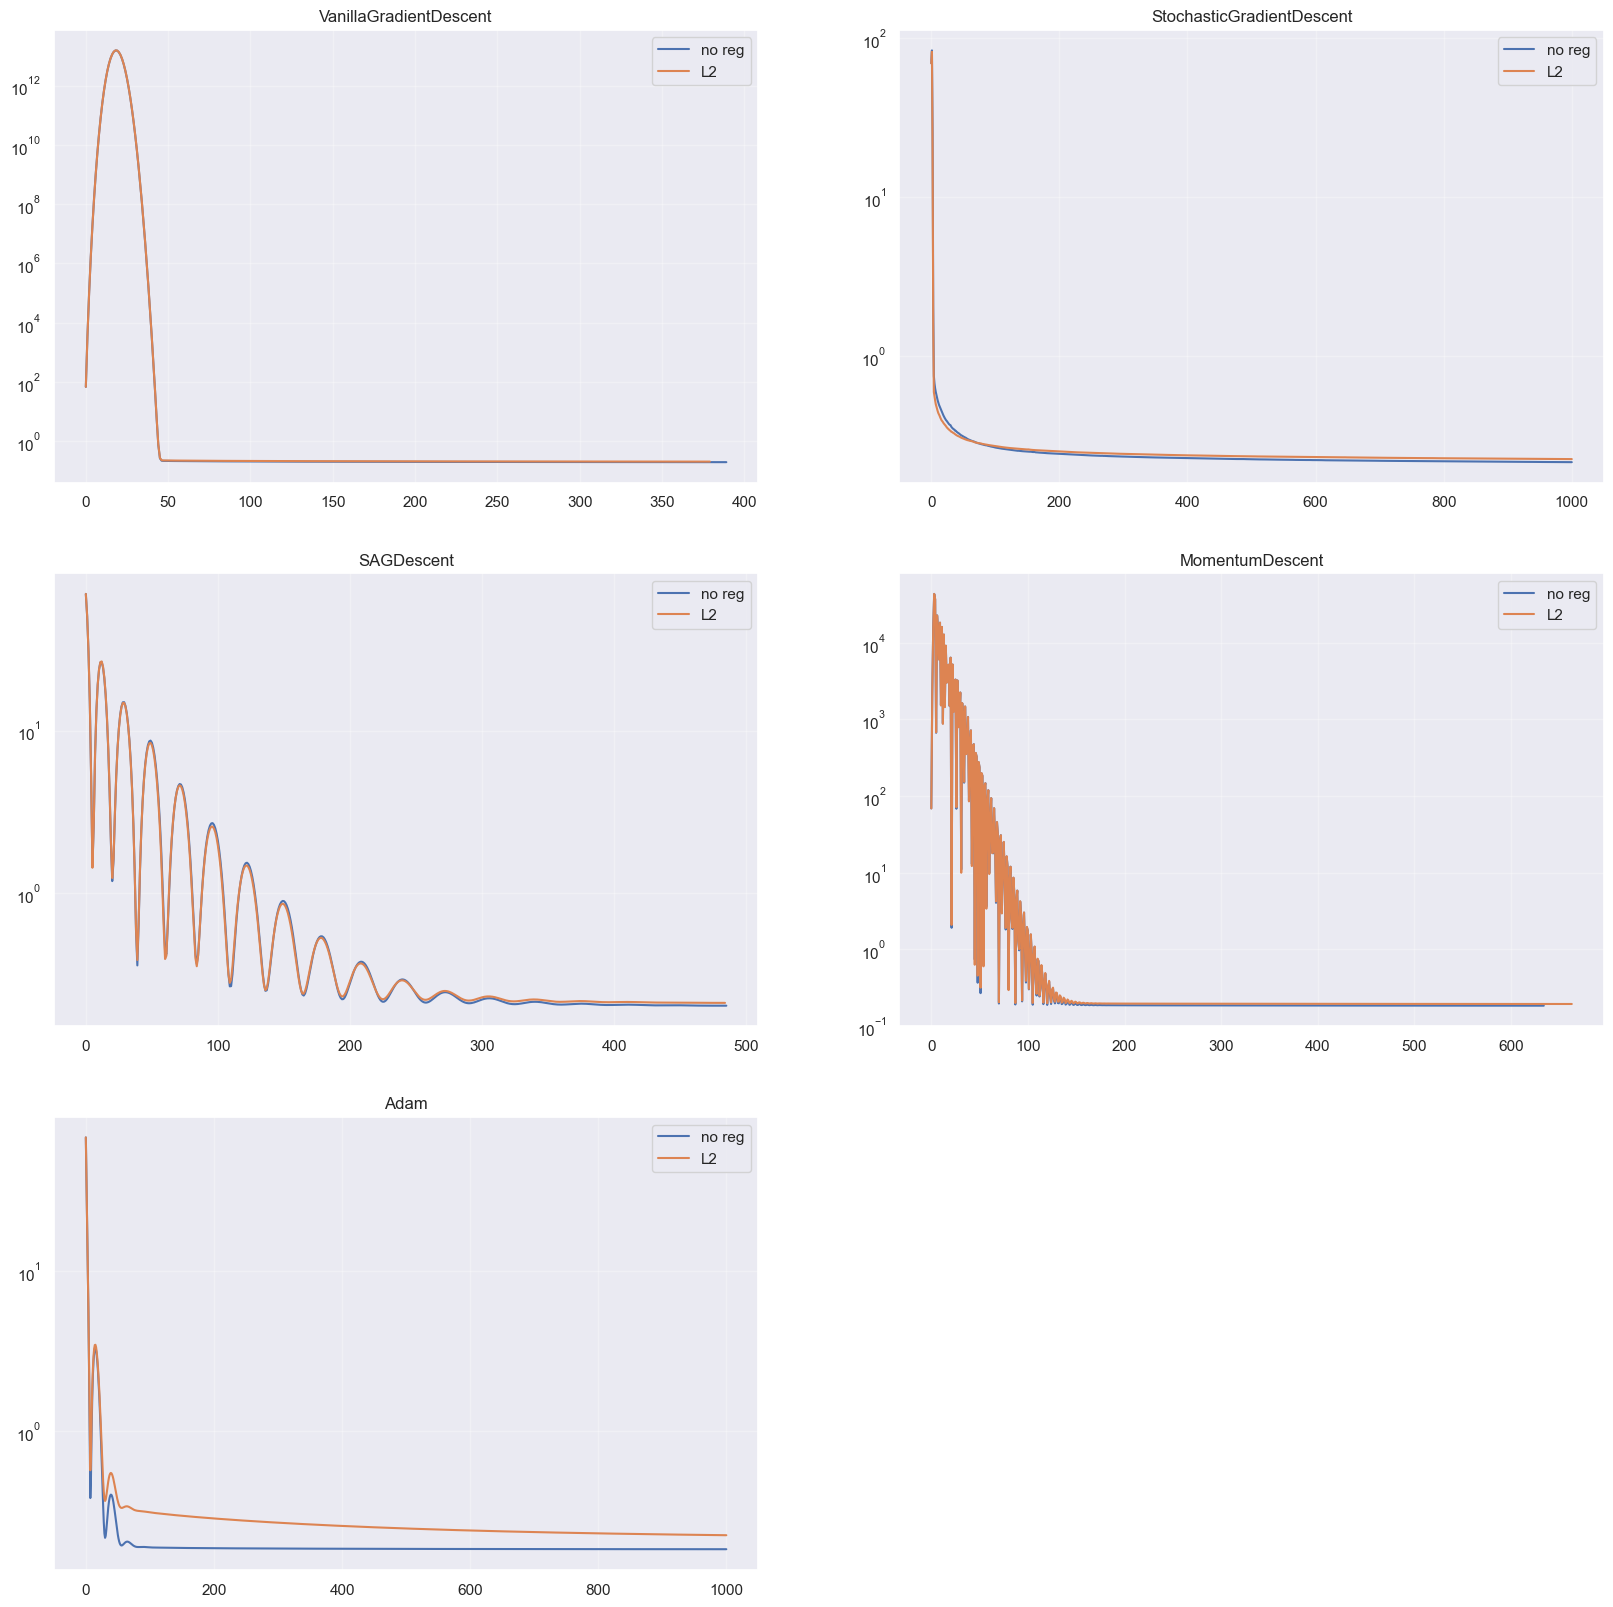

In [47]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(20, 20))
axes = axes.flatten()
for i, descent_model in enumerate(descent_models):
    name = descent_model.__name__
    axes[i].plot(mse_loss_history[name], label='no reg')
    axes[i].plot(reg_loss_history[name], label='L2')
    axes[i].set_yscale('log')
    axes[i].set_title(name)
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()
axes[5].set_visible(False)
plt.xlabel('Итерация')
plt.show()


### Результаты блока

L2-регуляризация почти не меняет скорость сходимости большинства методов, но стабилизирует обучение и снижает риск взрыва весов на неудачных learning rates. На графиках это особенно заметно для методов с резкими скачками loss.


## 7. Альтернативные функции потерь: LogCosh и Huber

Финальный эксперимент — заменить MSE на более робастные функции потерь. Это полезно для регрессии с выбросами: MSE сильно штрафует большие ошибки, а Huber/LogCosh ведут себя мягче.


In [48]:
from linear_models_gd import LogCoshLoss, HuberLoss


In [49]:
delta_grid = np.logspace(-1, 2, 8)

losses = {
    "LogCosh": LogCoshLoss(),
    "Huber": HuberLoss(delta=1.0),
}

new_loss_history = {}
new_params_history = {}

for loss_name, loss_fn in losses.items():
    loss_history = {}
    params_history = {}

    for descent_model in descent_models:
        best_val_loss = float("inf")
        best_lambda = None
        best_delta = None
        best_loss_hist = None
        num_iter = 0
        results = {}

        saved_batch = mse_params_history.get(descent_model.__name__, {}).get("batch_size", 32)
        current_lr_grid = grid[descent_model.__name__] if isinstance(grid, dict) else grid

        current_delta_grid = delta_grid if loss_name == "Huber" else [None]

        for d in current_delta_grid:
            current_loss_fn = HuberLoss(delta=d) if loss_name == "Huber" else loss_fn

            for lambd in current_lr_grid:
                if descent_model.__name__ in ["StochasticGradientDescent", "SAGDescent"]:
                    optimizer = descent_model(batch_size=saved_batch, lr_schedule=TimeDecayLR(lambda_=lambd))
                else:
                    optimizer = descent_model(lr_schedule=TimeDecayLR(lambda_=lambd))

                model = CustomLinearRegression(optimizer=optimizer, loss_function=current_loss_fn)
                model.fit(X_train, y_train)

                if not np.all(np.isfinite(model.w)):
                    continue

                val_loss = model.compute_loss(X_val, y_val)
                if np.isfinite(val_loss) and val_loss < best_val_loss:
                    best_val_loss = val_loss
                    best_lambda = lambd
                    best_delta = d
                    num_iter = optimizer.iteration
                    best_loss_hist = model.loss_history.copy()

                    mse = MSELoss()
                    results = {
                        "train_mse": mse.loss(X_train, y_train, model.w),
                        "val_mse": mse.loss(X_val, y_val, model.w),
                        "test_mse": mse.loss(X_test, y_test, model.w),
                        "train_r2": r2_score(y_train, model.predict(X_train)),
                        "val_r2": r2_score(y_val, model.predict(X_val)),
                        "test_r2": r2_score(y_test, model.predict(X_test)),
                    }

        loss_history[descent_model.__name__] = best_loss_hist
        params_history[descent_model.__name__] = {
            "lambda": best_lambda,
            "delta": best_delta,
            "iterations": num_iter,
            **results
        }

    new_loss_history[loss_name] = loss_history
    new_params_history[loss_name] = params_history


In [50]:
rows = []
for m in descent_models:
    name = m.__name__

    mse = mse_params_history[name]
    lc = new_params_history["LogCosh"][name]
    hb = new_params_history["Huber"][name]

    rows.append({
        "Model": name, "loss": "MSE",
        "lambda": mse["lambda"], "delta": None,
        "val_mse": mse["val_mse"], "train_mse": mse["train_mse"], "test_mse": mse["test_mse"],
        "train_r2": mse["train_r2"], "val_r2": mse["val_r2"], "test_r2": mse["test_r2"],
        "iters": mse["iterations"],
    })
    rows.append({
        "Model": name, "loss": "LogCosh",
        "lambda": lc["lambda"], "delta": None,
        "val_mse": lc["val_mse"], "train_mse": lc["train_mse"], "test_mse": lc["test_mse"],
        "train_r2": lc["train_r2"], "val_r2": lc["val_r2"], "test_r2": lc["test_r2"],
        "iters": lc["iterations"],
    })
    rows.append({
        "Model": name, "loss": "Huber",
        "lambda": hb["lambda"], "delta": hb.get("delta", None),
        "val_mse": hb["val_mse"], "train_mse": hb["train_mse"], "test_mse": hb["test_mse"],
        "train_r2": hb["train_r2"], "val_r2": hb["val_r2"], "test_r2": hb["test_r2"],
        "iters": hb["iterations"],
    })

df_losses = pd.DataFrame(rows)

display(
    df_losses.style
      .format({
          "lambda": "{:.6f}",
          "delta": lambda x: "-" if pd.isna(x) else f"{x:.3g}",
          "val_mse": "{:.6f}", "train_mse": "{:.6f}", "test_mse": "{:.6f}",
          "train_r2": "{:.6f}", "val_r2": "{:.6f}", "test_r2": "{:.6f}",
          "iters": lambda x: f"{int(x)}",
      })
      .hide(axis="index")
)


Model,loss,lambda,delta,val_mse,train_mse,test_mse,train_r2,val_r2,test_r2,iters
VanillaGradientDescent,MSE,1.291550,-,0.199278,0.199361,0.203880,0.828386,0.829006,0.823530,389
VanillaGradientDescent,LogCosh,10.000000,-,0.191037,0.191297,0.196579,0.835327,0.836077,0.829849,757
VanillaGradientDescent,Huber,10.000000,0.1,0.216153,0.217169,0.221705,0.813056,0.814526,0.808102,445
StochasticGradientDescent,MSE,0.316228,-,0.213614,0.214116,0.218046,0.815684,0.816704,0.811268,1000
StochasticGradientDescent,LogCosh,3.162278,-,0.197145,0.197575,0.202446,0.829923,0.830836,0.824771,1000
StochasticGradientDescent,Huber,3.162278,0.1,0.239988,0.242244,0.246479,0.791471,0.794074,0.786658,841
SAGDescent,MSE,1.000000,-,0.204163,0.204326,0.208579,0.824112,0.824814,0.819463,485
SAGDescent,LogCosh,1.000000,-,0.233531,0.234454,0.238215,0.798177,0.799615,0.793811,533
SAGDescent,Huber,1.000000,0.1,0.568039,0.571155,0.574927,0.508336,0.512584,0.502367,776
MomentumDescent,MSE,1.000000,-,0.184445,0.184233,0.189547,0.841408,0.841734,0.835936,634


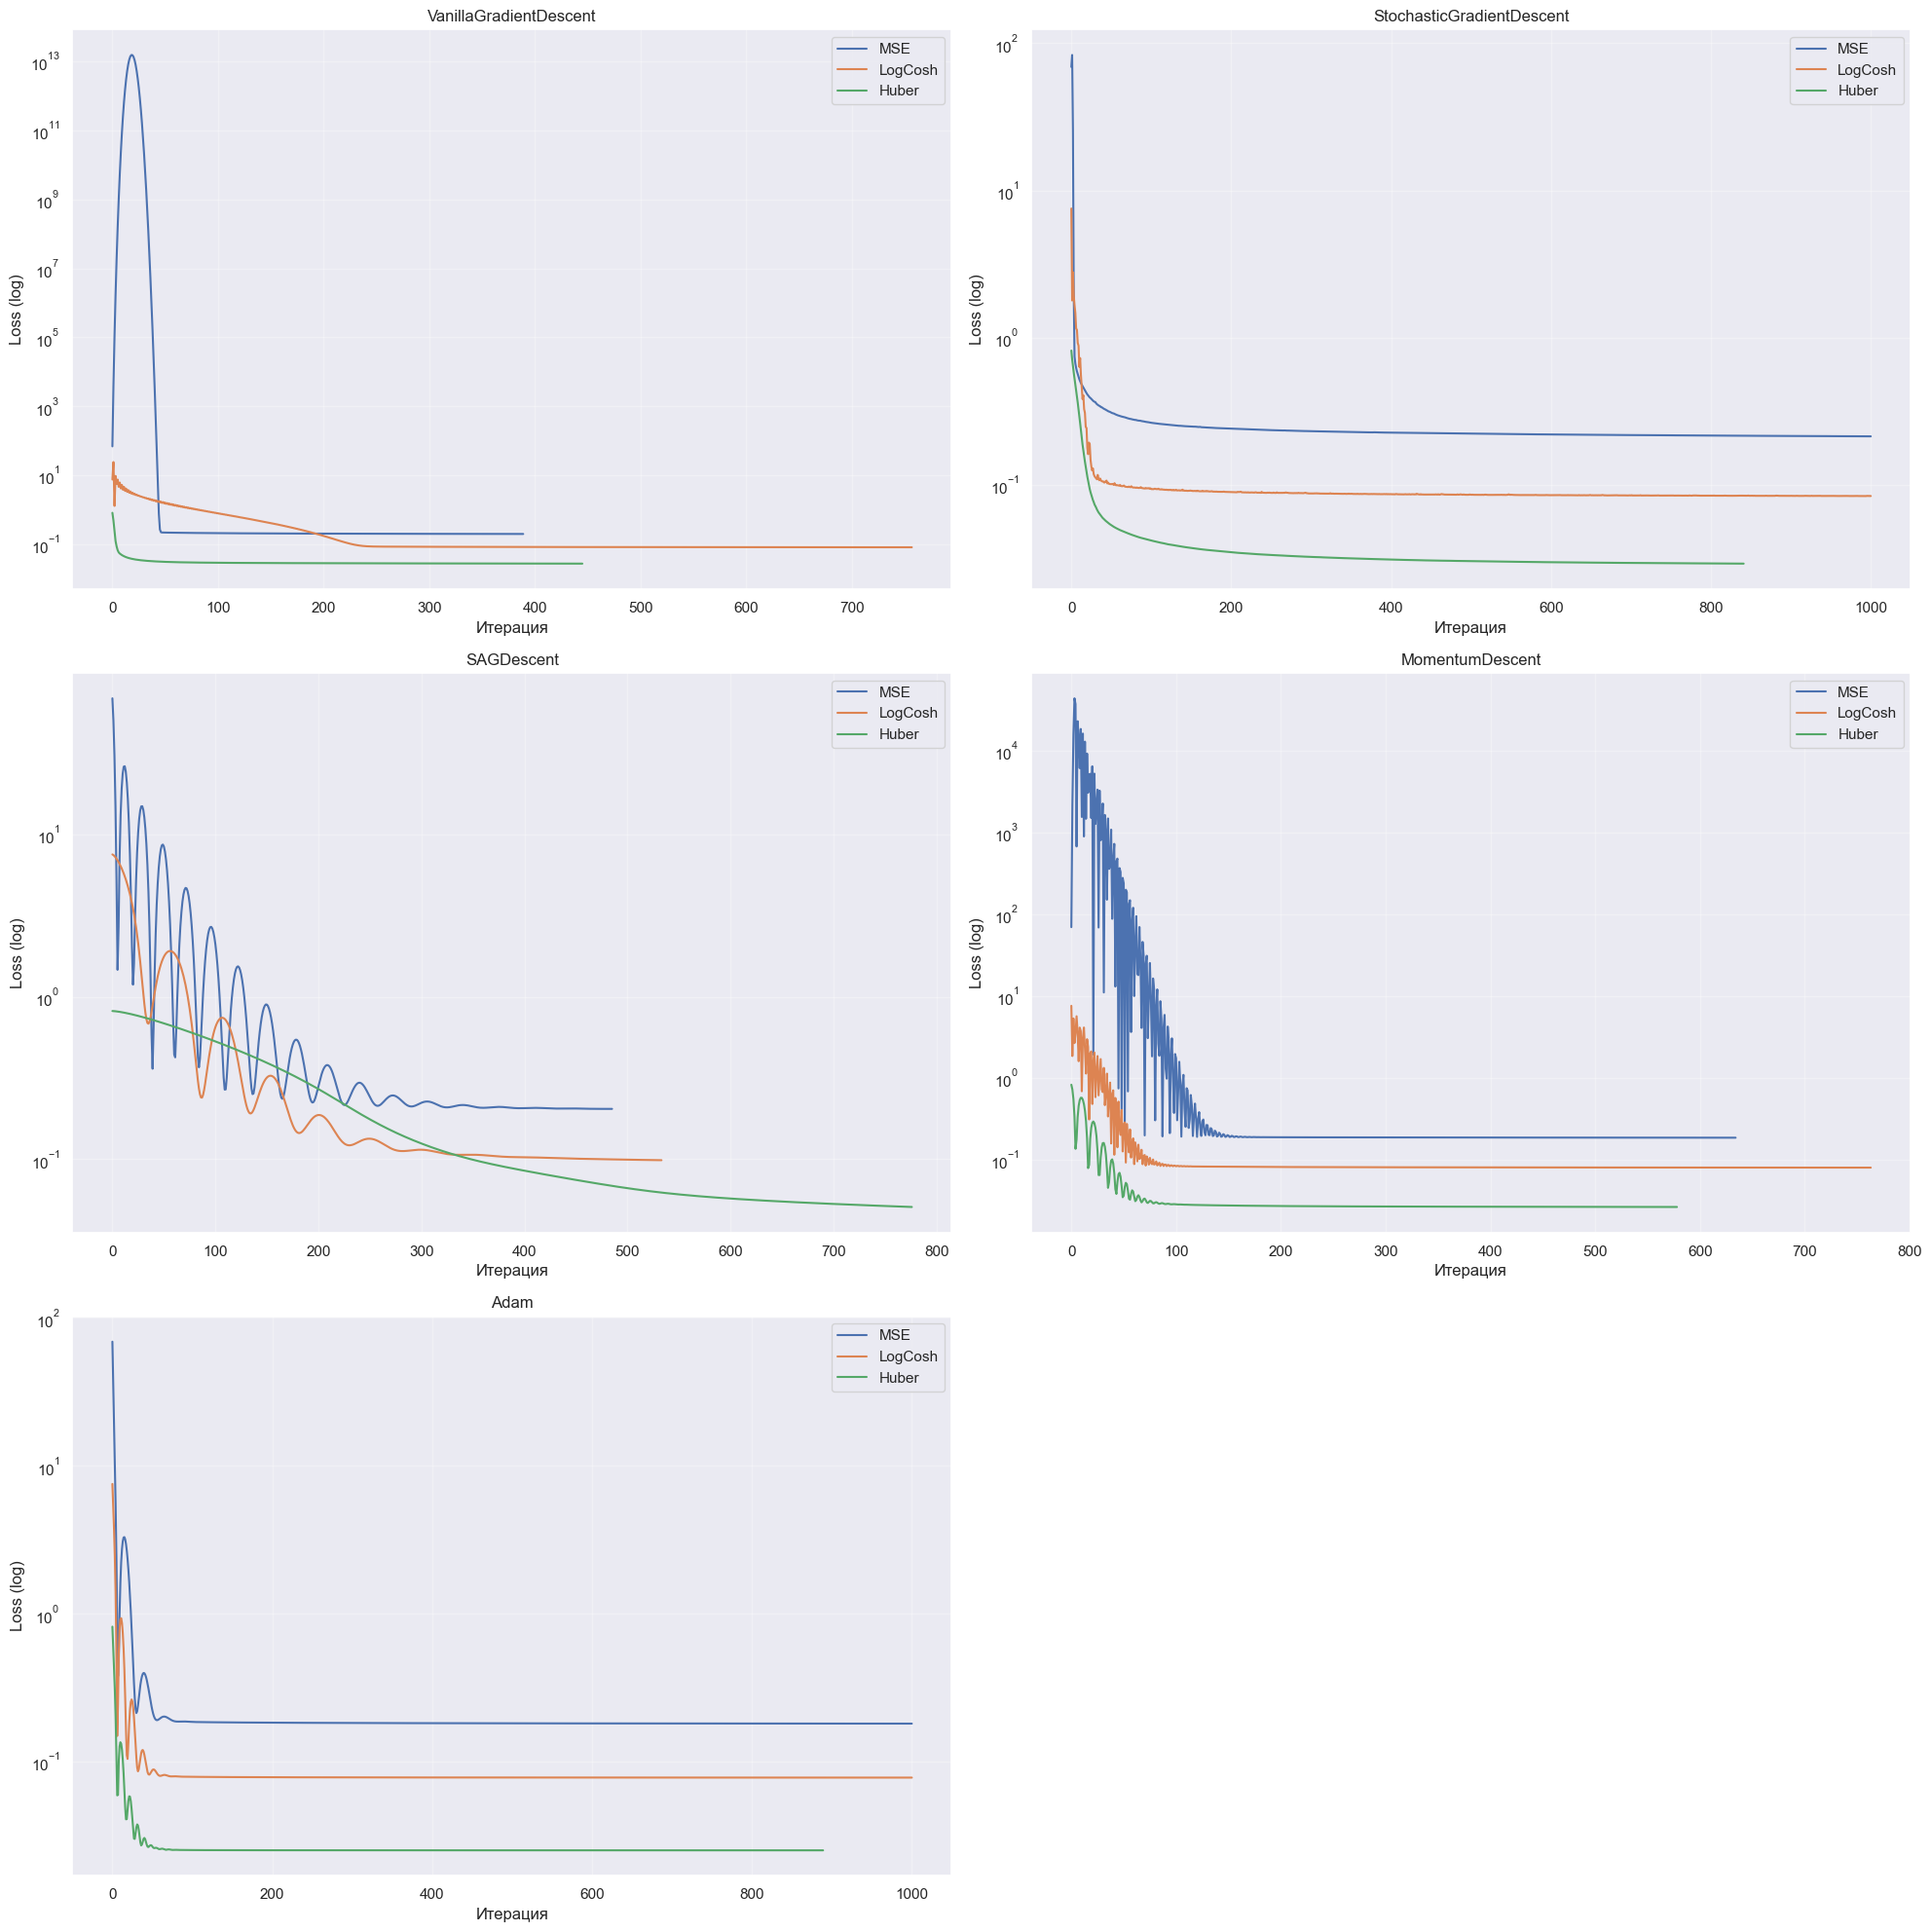

In [51]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(20, 20))
axes = axes.flatten()

for i, descent_model in enumerate(descent_models):
    name = descent_model.__name__
    h_logcosh = new_loss_history["LogCosh"].get(name)
    h_huber = new_loss_history["Huber"].get(name)
    h_mse = mse_loss_history.get(name)
    if h_mse is not None:
        axes[i].plot(h_mse, label="MSE")
    if h_logcosh is not None:
        axes[i].plot(h_logcosh, label="LogCosh")
    if h_huber is not None:
        axes[i].plot(h_huber, label="Huber")
    axes[i].set_yscale("log")
    axes[i].set_title(name)
    axes[i].set_xlabel("Итерация")
    axes[i].set_ylabel("Loss (log)")
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()
axes[5].set_visible(False)
plt.tight_layout()
plt.show()


### Результаты блока

Huber и LogCosh уменьшают резкие всплески loss по сравнению с MSE. Особенно это видно на Vanilla GD и Momentum: MSE может провоцировать большие скачки, а робастные функции потерь делают траекторию оптимизации спокойнее.


## Итоги

- Реализована модульная линейная регрессия с разными loss functions и optimizers.
- SVD closed-form solution устойчивее naive inverse при мультиколлинеарности.
- На задаче предсказания `log_price` лучшие результаты дали Adam и Momentum.
- Batch size существенно влияет на SGD: слишком маленькие батчи дают шумную и нестабильную оптимизацию.
- L2 и robust losses повышают устойчивость обучения на выбросах и неудачных learning rates.
